# SDR Lab: Noise Analysis and FM Reception
**Duration:** 2 hours  
**Date:** August 2025

**Getting started link:** https://pysdr.org/content/pluto.html

## Learning Objectives:
1. Understand complex signal representation in SDR
2. Analyze noise characteristics empirically
3. Implement FM demodulation
4. Work with time and frequency domain representations

---
**About this version:** this notebook is the main lab. The TODO cells below include extra
*hint comments* drawn from two other sources so students have more to work from:
- an earlier, simpler introductory draft of this lab, and
- `fm_radio.py`, a polished, production-style real-time FM receiver script.

These are comments only — the TODOs are still yours to complete. Some hints point out a
simpler alternative approach; others point out a production-quality trick (persistent filter
state, de-emphasis filtering, non-blocking audio streaming, etc.) that goes beyond what's
strictly required for the lab but is good to know about.

In [1]:
# Install required packages
!pip install matplotlib numpy scipy sounddevice

Defaulting to user installation because normal site-packages is not writeable


In [2]:
import numpy as np
import adi
import matplotlib.pyplot as plt
from scipy import stats
from scipy.signal import resample
import sounddevice as sd
import time

# Configure PlutoSDR
sample_rate = 1e6 # Hz
center_freq = 102e7 # Hz (empty-spectrum baseline for noise analysis; we retune for FM later)
num_samps = 100000 # number of samples returned per call to rx()

# NOTE: update this IP to match your actual Pluto device.
# Different drafts/scripts in this lab series have used 192.168.2.1, 192.168.2.7, and
# 192.168.3.1 - check your Pluto's USB/network config if you're not sure which is yours.
sdr = adi.Pluto('ip:192.168.2.1')

# Gain: this lab uses manual gain so power readings are directly comparable across frequencies.
# For a *deployed* receiver (see fm_radio.py) you'd typically use AGC instead:
#   sdr.gain_control_mode_chan0 = 'slow_attack'
# which continuously adjusts gain for you - convenient for long unattended playback, but
# less useful here since we want repeatable measurements between bands.
sdr.gain_control_mode_chan0 = 'manual'
sdr.rx_hardwaregain_chan0 = 70.0 # dB
sdr.rx_lo = int(center_freq)
sdr.sample_rate = int(sample_rate)
sdr.rx_rf_bandwidth = int(sample_rate) # filter width, just set it to the same as sample rate for now
sdr.rx_buffer_size = num_samps

# Optional (from fm_radio.py): flush a few buffers right after (re)configuring the SDR.
# The first few rx() calls after retuning can contain stale/settling samples.
# for _ in range(10):
#     _ = sdr.rx()

print("PlutoSDR configured successfully!")

PlutoSDR configured successfully!


# Part 1: Receiving and Analyzing Noise  

First, let's receive some samples and understand what we're getting from the SDR.

In [3]:
# Receive initial samples
samples = sdr.rx() # receive samples off Pluto
print(f"Received {len(samples)} samples")
print(f"First 10 samples: {samples[:10]}")
print(f"Sample data type: {samples.dtype}")

Received 100000 samples
First 10 samples: [-2.-14.j 13.-16.j 12.-20.j 12.-15.j 23.-15.j 22. -6.j 14.-18.j 11. -7.j
 -2.+11.j 19. +2.j]
Sample data type: complex128


## Task 1: Collect More Samples  
Put the `samples = sdr.rx()` in a loop and collect more samples. Store them in a variable called `more_samples`. Collect at least 5 iterations worth of samples.

In [4]:
# Task 1: Your code here
# Collect multiple batches of samples
more_samples = []
# TODO: Write a loop to collect 5 batches of samples# Task 1: Collect multiple batches of samples

more_samples = []

for _ in range(5):
    batch = sdr.rx()
    more_samples.append(batch)

# Convert list of arrays into one numpy array
more_samples = np.concatenate(more_samples)

# Hint (from the intro lab draft): the simplest version of this loop is
""" for _ in range(5):
       batch = sdr.rx()
       more_samples.append(batch)"""
#
# sdr.rx() already returns a numpy array each call, so once you're done collecting,
# np.concatenate(more_samples) is usually cleaner than converting a list of arrays
# directly with np.array(more_samples).

# Convert to numpy array for easier processing

print(f"Total samples collected: {len(more_samples)}")

Total samples collected: 500000


## Task 2: Scatter Plot Analysis  
Create a scatter plot of the real vs imaginary parts of your samples. This is called a "constellation diagram" in communications.

**Your task:** Plot np.real(more_samples) vs np.imag(more_samples) using plt.scatter(). Use only the first 10,000 samples for clarity.

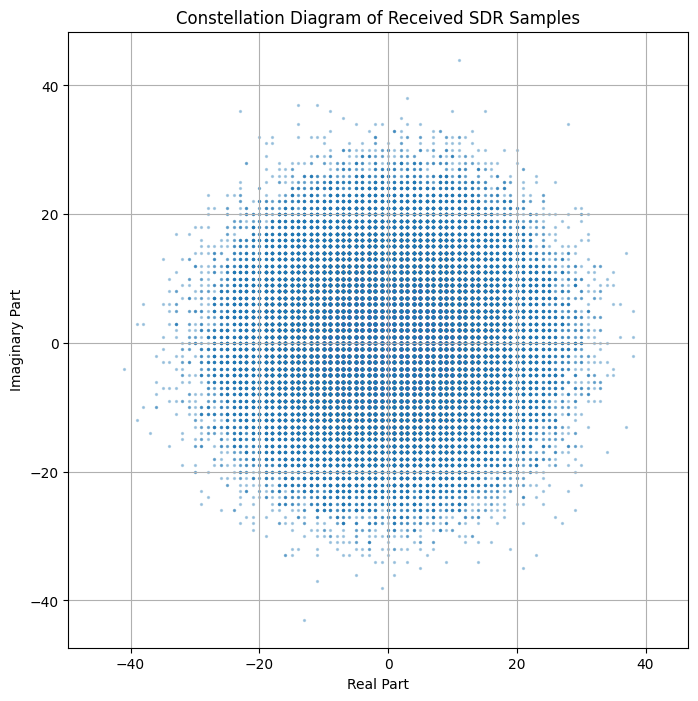

In [5]:
# Task 2: Create scatter plot here
# Extract real and imaginary parts
real_part = np.real(more_samples)
imag_part = np.imag(more_samples)
# TODO: Create scatter plot of real vs imaginary parts
# - Use plt.figure() to set the figure size to (8, 8)
# - Create a scatter plot of real_part vs imag_part (first 100000 samples)
# - Set appropriate title, xlabel, ylabel
# - Add grid and ensure equal axis scaling
# - Display the plot
# Task 2: Create scatter plot here

# Extract real and imaginary parts

plt.figure(figsize=(8, 8))

plt.scatter(
    real_part[:100000],
    imag_part[:100000],
    s=2,
    alpha=0.3
)

plt.title("Constellation Diagram of Received SDR Samples")
plt.xlabel("Real Part")
plt.ylabel("Imaginary Part")

plt.grid(True)
plt.axis('equal')

plt.show()
# Hint: with this many points, plt.scatter(..., s=2, alpha=0.3) reads much better than the
# default marker size/opacity - a big solid blob won't show you the shape of the noise cloud.
# e.g.: plt.scatter(real_part[:10000], imag_part[:10000], s=2, alpha=0.3)
#       plt.axis('equal')   # keeps the constellation circular instead of stretched

## Task 3: Histogram Analysis 
Plot histograms of the real and imaginary parts separately. Then analyze their statistical distributions.

**Your task:**
1. Create histograms of real_part and imag_part using plt.hist()
2. Fit Gaussian distributions using stats.norm.fit()
3. Overlay the fitted distributions on your histograms

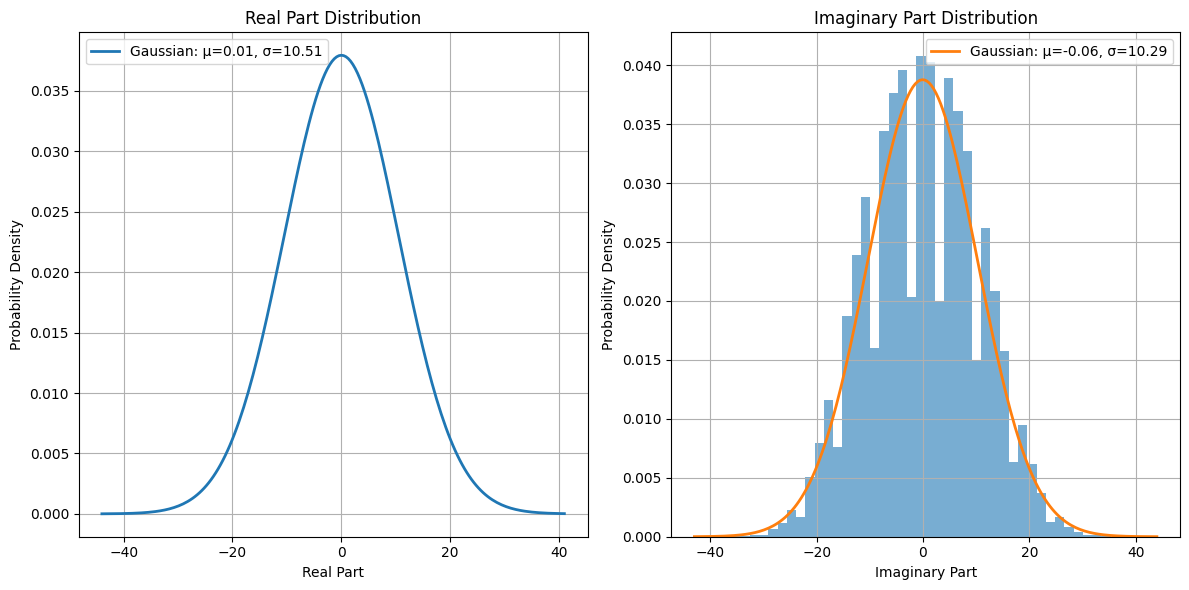

In [6]:
# Task 3: Histogram analysis with distribution fitting
import scipy.stats as stats
# Extract real and imaginary parts
real_part = np.real(more_samples)
imag_part = np.imag(more_samples)

# TODO: Create side-by-side histograms for real and imaginary parts
real_mu, real_sigma = stats.norm.fit(real_part)
imag_mu, imag_sigma = stats.norm.fit(imag_part)
# Hint: Use plt.figure() with figsize=(12, 6) and plt.subplot(1, 2, 1) for left plot
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)

# TODO: Fit Gaussian distributions to both real and imaginary parts
# Hint: Use stats.norm.fit(data) which returns (mu, sigma)
x_real = np.linspace(real_part.min(), real_part.max(), 200)
pdf_real = stats.norm.pdf(x_real, real_mu, real_sigma)
# TODO: Plot the fitted Gaussian curves over the histograms
# Hint: Create x values using np.linspace() and calculate PDF using stats.norm.pdf()
# Add the curves to both subplots with appropriate labels showing mu and sigma values
plt.plot(
    x_real,
    pdf_real,
    linewidth=2,
    label=f"Gaussian: μ={real_mu:.2f}, σ={real_sigma:.2f}"
)
plt.title("Real Part Distribution")
plt.xlabel("Real Part")
plt.ylabel("Probability Density")
plt.grid(True)
plt.legend()


plt.subplot(1, 2, 2)

plt.hist(imag_part, bins=50, density=True, alpha=0.6)

x_imag = np.linspace(imag_part.min(), imag_part.max(), 200)
pdf_imag = stats.norm.pdf(x_imag, imag_mu, imag_sigma)

plt.plot(
    x_imag,
    pdf_imag,
    linewidth=2,
    label=f"Gaussian: μ={imag_mu:.2f}, σ={imag_sigma:.2f}"
)

plt.title("Imaginary Part Distribution")
plt.xlabel("Imaginary Part")
plt.ylabel("Probability Density")
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()


# Extra hint: plt.hist(..., density=True) is what lets you overlay a PDF directly - without
# density=True the histogram counts and the Gaussian PDF end up on different y-scales.

## Task 4: Analysis Questions (10 minutes)
Based on your plots and statistical analysis above, answer these questions:

1. **What distribution do the real and imaginary parts follow?**
   - Looking at the histograms and statistical fits, what can you conclude?

2. **What does the constellation diagram tell us?**
   - Is there any structure or is it random?

3. **Are the real and imaginary parts correlated?**
   - Do they appear to be independent?

**Expected observations:**
- The data should show characteristics of **complex Gaussian noise** (AWGN - Additive White Gaussian Noise)
- Both I and Q components should be approximately Gaussian with similar variances
- The constellation should appear as a circular cloud centered around the origin
- This is what we expect when receiving thermal noise

## Task 5: Frequency Analysis (5 minutes)
Try different frequencies to find where you receive only noise vs actual signals.

**Your task:** Test these frequencies and compare their power spectra:
- 88 MHz (Low end of FM band)
- 95 MHz (Mid FM band)
- 103 MHz (Your original frequency)
- 108 MHz (High end of FM band)
- 400 MHz (Empty spectrum area)

Frequency: 880 MHz, Max Power: 14.6 dBm/Hz, Avg Noise Floor: -9.1 dBm/Hz
Frequency: 950 MHz, Max Power: 14.3 dBm/Hz, Avg Noise Floor: -9.3 dBm/Hz
Frequency: 1030 MHz, Max Power: 27.0 dBm/Hz, Avg Noise Floor: -9.8 dBm/Hz
Frequency: 1080 MHz, Max Power: 27.4 dBm/Hz, Avg Noise Floor: 7.9 dBm/Hz
Frequency: 400 MHz, Max Power: 23.3 dBm/Hz, Avg Noise Floor: 2.7 dBm/Hz


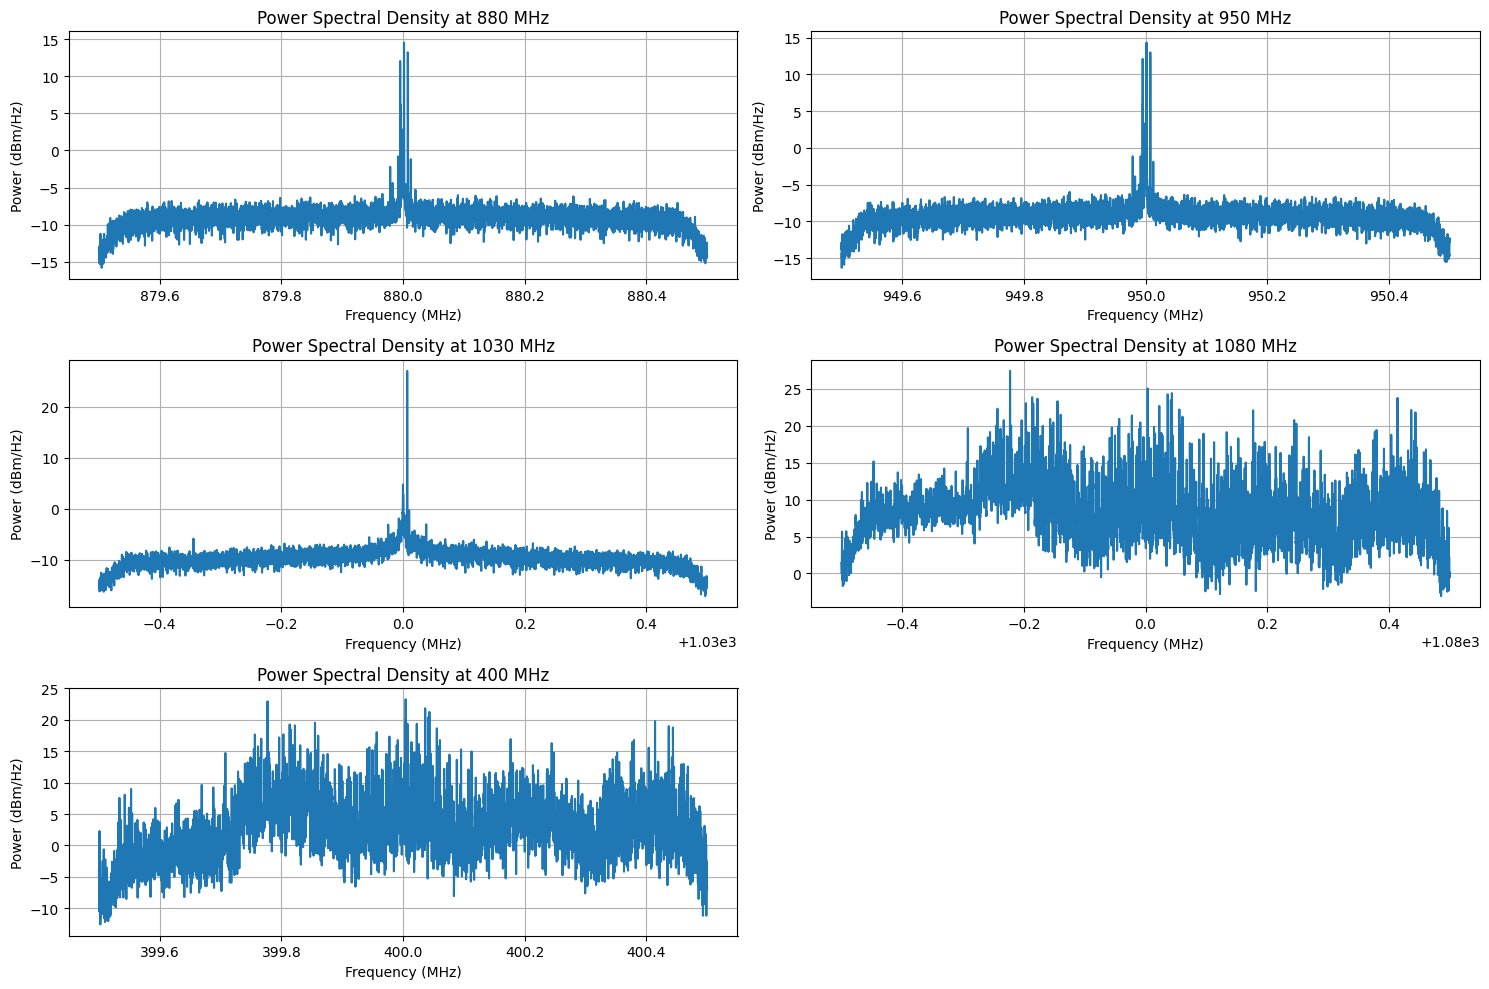

Reset to original frequency: 1020.0 MHz

Note: Using Welch's method for better PSD estimation with averaging and windowing


In [11]:

# Task 5: Test different frequencies
test_frequencies = [88e7, 95e7, 103e7, 108e7, 40e7]

# Import scipy for PSD functions
from scipy import signal

# Create figure for subplots
plt.figure(figsize=(15, 10))

# Loop through each frequency and analyze the signal
for i, freq in enumerate(test_frequencies):
    # Set the SDR receiver frequency
    sdr.rx_lo = int(freq)

    # Collect samples
    samples = sdr.rx()

    # Calculate PSD using Welch's method (much better than manual FFT)
    freqs_psd, psd = signal.welch(samples, fs=sample_rate,
                                  window='hann', nperseg=8192,
                                  return_onesided=False, scaling='density')

    # Shift to center the spectrum
    freqs_shifted = np.fft.fftshift(freqs_psd)
    psd_shifted = np.fft.fftshift(psd)

    # Convert to actual frequencies (add center frequency)
    actual_freqs = freqs_shifted + freq

    # Convert to dBm/Hz
    psd_dbm = 10 * np.log10(psd_shifted + 1e-20) + 30

    # Create subplot
    plt.subplot(3, 2, i+1)
    plt.plot(actual_freqs/1e6, psd_dbm)
    plt.title(f'Power Spectral Density at {freq/1e6:.0f} MHz')
    plt.xlabel('Frequency (MHz)')
    plt.ylabel('Power (dBm/Hz)')
    plt.grid(True)

    # Print statistics
    max_power_dbm = np.max(psd_dbm)
    avg_noise_floor = np.mean(psd_dbm)
    print(f"Frequency: {freq/1e6:.0f} MHz, Max Power: {max_power_dbm:.1f} dBm/Hz, Avg Noise Floor: {avg_noise_floor:.1f} dBm/Hz")

plt.tight_layout()
plt.show()

# Reset to original frequency
sdr.rx_lo = int(center_freq)
print(f"Reset to original frequency: {center_freq/1e6:.1f} MHz")
print("\nNote: Using Welch's method for better PSD estimation with averaging and windowing")

# Hint for interpretation: watch for one test frequency with a noticeably higher max power
# AND a raised noise floor compared to the others - that's a real signal, not just noise.
# (In an earlier run of this exact sweep, 108 MHz stood out this way - worth checking whether
# that holds at your location too.)"""

# Part 2: FM Radio Reception and Demodulation (75 minutes)

## Setup Audio System

In [8]:
# Test audio system
print("Available audio devices:")
print(sd.query_devices())

# Test with a simple tone
print("\nTesting audio system with 1kHz tone for 1 second...")
test_tone = np.sin(2 * np.pi * 1000 * np.linspace(0, 1, 44100))
try:
    sd.play(test_tone, samplerate=44100)
    sd.wait()  # Wait until the sound finishes playing
    print("Audio test successful!")
except Exception as e:
    print(f"Audio test failed: {e}")
    print("You may not hear audio, but demodulation analysis will still work.")

Available audio devices:
  0 HDA NVidia: HDMI 0 (hw:0,3), ALSA (0 in, 8 out)
  1 HDA NVidia: HDMI 1 (hw:0,7), ALSA (0 in, 8 out)
  2 HDA NVidia: HDMI 2 (hw:0,8), ALSA (0 in, 8 out)
  3 HDA NVidia: HDMI 3 (hw:0,9), ALSA (0 in, 8 out)
  4 HD-Audio Generic: HDMI 0 (hw:1,3), ALSA (0 in, 8 out)
  5 HD-Audio Generic: ALC256 Analog (hw:2,0), ALSA (2 in, 2 out)
  6 hdmi, ALSA (0 in, 8 out)
  7 pulse, ALSA (32 in, 32 out)
* 8 default, ALSA (32 in, 32 out)

Testing audio system with 1kHz tone for 1 second...
Audio test successful!


## Task 6: Implement FM Demodulation (30 minutes)

Receiving FM samples...
Received 100000 samples

Step 1: Extracting instantaneous phase...
Phase range: -3.113 to 3.142 radians

Step 2: Unwrapping phase...
Unwrapped phase range: -1.681 to 2755.094 radians

Step 3: Computing derivative (instantaneous frequency)...
Instantaneous frequency in Hz: -500000.0 to 500000.0 Hz


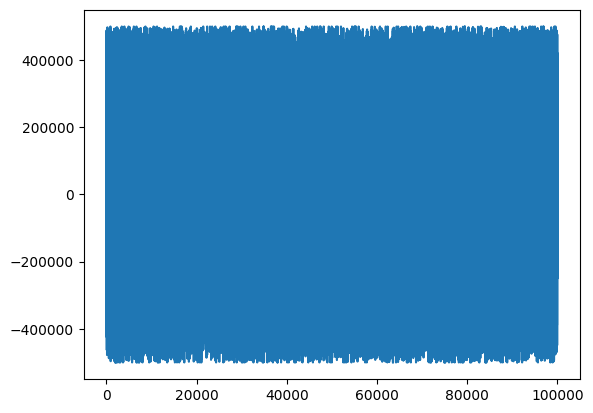

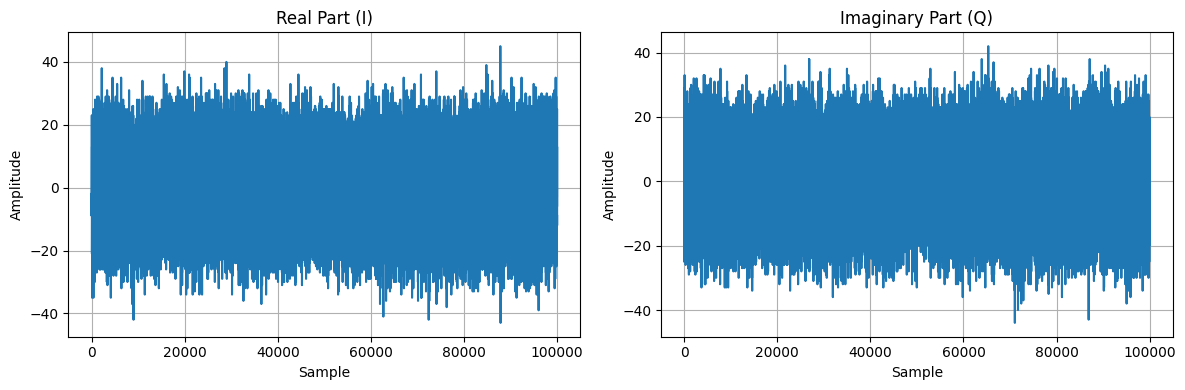

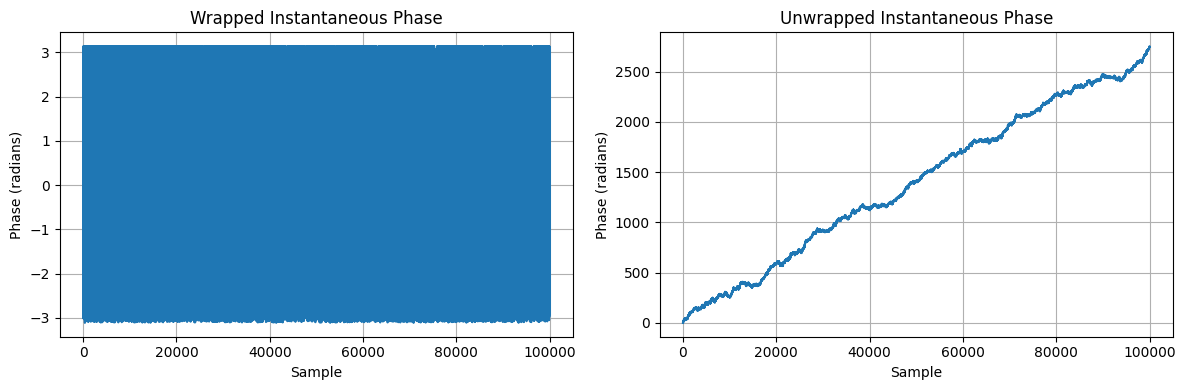

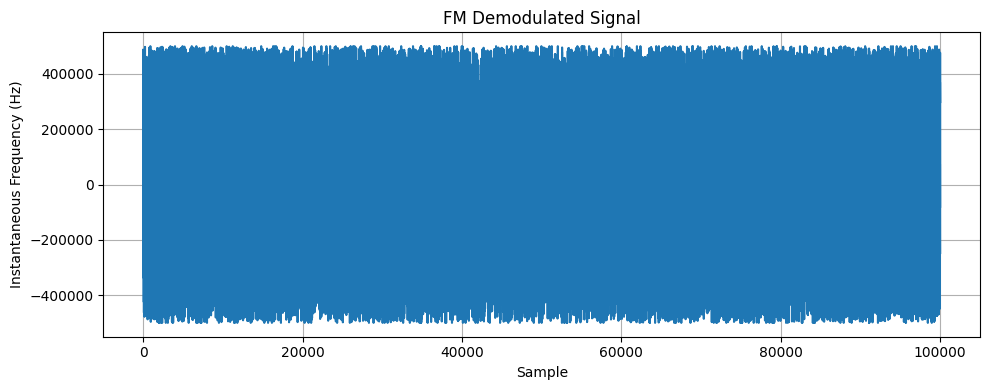

In [18]:
# Task 6: Step-by-step FM demodulation implementation
# First, let's receive some samples at FM frequency
print("Receiving FM samples...")
fm_samples = sdr.rx()
print(f"Received {len(fm_samples)} samples")

# Step 1: Extract the instantaneous phase
print("\nStep 1: Extracting instantaneous phase...")
# TODO: Complete this line - extract phase using np.angle()
instantaneous_phase = np.angle(fm_samples)# e.g. np.angle(fm_samples)
unwrapped_phase = np.unwrap(instantaneous_phase)

print(f"Phase range: {np.min(instantaneous_phase):.3f} to {np.max(instantaneous_phase):.3f} radians")

# Step 2: Unwrap the phase to handle discontinuities
print("\nStep 2: Unwrapping phase...")
# TODO: Complete this line - unwrap phase using np.unwrap()
unwrapped_phase = np.unwrap(instantaneous_phase)
  # e.g. np.unwrap(instantaneous_phase)

print(f"Unwrapped phase range: {np.min(unwrapped_phase):.3f} to {np.max(unwrapped_phase):.3f} radians")

# Step 3: Take the derivative to get instantaneous frequency
print("\nStep 3: Computing derivative (instantaneous frequency)...")
# TODO: Complete this line - take the derivative using np.diff()
instantaneous_frequency = np.diff(unwrapped_phase) # e.g. np.diff(unwrapped_phase)

# Convert from radians per sample to Hz
instantaneous_message = instantaneous_frequency * sample_rate / (2 * np.pi)
print(f"Instantaneous frequency in Hz: {np.min(instantaneous_message):.1f} to {np.max(instantaneous_message):.1f} Hz")

# Hint: there's a one-line shortcut for Steps 1-3 combined, used in the intro lab draft and in
# fm_radio.py - multiplying each sample by the complex conjugate of the previous one folds the
# phase difference into a single np.angle() call, with no separate unwrap/diff step needed:
#   demod = np.angle(fm_samples[1:] * np.conj(fm_samples[:-1]))
# Implementing Steps 1-3 explicitly first is worth doing so you understand *why* that shortcut
# works (phase unwrapping is exactly what's needed when consecutive phases jump across the
# +-pi boundary) - the two approaches should give equivalent results, which is a good way to
# check your work.

# TODO: Create plots to visualize each step of the process
# Plot 1: Original signal (real and imaginary parts)
# - Create figure with size (12, 4)
# - Use 1x2 subplots
# - Left: plot real part, Right: plot imaginary part
# - Add appropriate titles and labels

np.real(fm_samples)
np.imag(fm_samples)


# Plot 2: Instantaneous phase (wrapped and unwrapped)  
# - Create figure with size (12, 4)
# - Use 1x2 subplots
# - Left: plot wrapped phase, Right: plot unwrapped phase
# - Add appropriate titles and labels
plt.plot(instantaneous_message)

# Plot 3: Demodulated signal (instantaneous frequency)
# - Create figure with size (10, 4) 
# - Plot the instantaneous_message
# - Add title, labels, and grid

#
# Plot 1: Original IQ Signal


plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(np.real(fm_samples))
plt.title("Real Part (I)")
plt.xlabel("Sample")
plt.ylabel("Amplitude")
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(np.imag(fm_samples))
plt.title("Imaginary Part (Q)")
plt.xlabel("Sample")
plt.ylabel("Amplitude")
plt.grid(True)

plt.tight_layout()
plt.show()



# Plot 2: Wrapped and Unwrapped Phase

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(instantaneous_phase)
plt.title("Wrapped Instantaneous Phase")
plt.xlabel("Sample")
plt.ylabel("Phase (radians)")
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(unwrapped_phase)
plt.title("Unwrapped Instantaneous Phase")
plt.xlabel("Sample")
plt.ylabel("Phase (radians)")
plt.grid(True)

plt.tight_layout()
plt.show()



# Plot 3: Demodulated Signal


plt.figure(figsize=(10, 4))

plt.plot(instantaneous_message)
plt.title("FM Demodulated Signal")
plt.xlabel("Sample")
plt.ylabel("Instantaneous Frequency (Hz)")
plt.grid(True)

plt.tight_layout()
plt.show()

## Task 7: Audio Processing and Playback (25 minutes)
Now let's process the demodulated signal for audio playback.

**Your task:**
1. Remove DC component from the demodulated signal
2. Resample from 1 MHz to 44.1 kHz using `resample()`
3. Normalize the signal for audio playback
4. Play the audio using `sd.play()`

> **Note:** there isn't a separate code cell for this task - you'll implement it as the
> `audio_processing_function()` inside the Task 8 cell below, since in a real-time receiver
> audio processing has to happen as part of the same per-chunk loop as demodulation.
> For reference, `fm_radio.py` also folds a 15 kHz low-pass filter and a 75us de-emphasis
> filter into this stage - not required here, but worth knowing about if your demodulated
> audio sounds harsher/hissier than a real FM receiver.

## Task 8: Real-time FM Demodulation (20 minutes)
Let's create a real-time version that continuously demodulates FM radio.

**Your task:** Complete the FM demodulation function and run it in a loop for real-time processing.

In [21]:
# Task 8: Real-time FM demodulation
print("Starting real-time FM demodulation...")
print("This will run for 30 seconds. Press Ctrl+C to stop early.")

def fm_demodulation_function(samples, last_phase):
    """Complete the FM demodulation function"""
    # TODO: Implement the complete FM demodulation pipeline
    # Step 1: Extract phase using np.angle()
    phase = np.angle(samples)

    # Step 2: Unwrap phase, incorporating last phase for continuity
    # Hint: Concatenate last_phase with current phase, unwrap, then remove first element
    #   e.g. unwrapped_phase = np.unwrap(np.concatenate(([last_phase], phase)))[1:]
  
    combined_phase = np.concatenate(([last_phase], phase))
    unwrapped_phase = np.unwrap(combined_phase)[1:]

    # Step 3: Differentiate to get instantaneous frequency using np.diff()
    inst_message = np.diff(unwrapped_phase)

    # TODO: Convert from radians/sample to Hz
    # Multiply by sample_rate/(2*pi)
    inst_message_hz = inst_message_hz = inst_message * sample_rate / (2 * np.pi)

    # Return both demodulated signal and the last phase value for next iteration
    return inst_message_hz, unwrapped_phase[-1]

def audio_processing_function(demod_signal, target_length):
    """Process demodulated signal for audio playback"""
    # TODO: Implement audio processing
    # Step 1: Resample to audio rate using resample()
    audio_signal = demod_signal - np.mean(demod_signal)
    audio_signal = resample(demod_signal, target_length)


    # Step 2: Normalize audio
    # Check if signal has any amplitude, then normalize to prevent clipping
    if np.max(np.abs(audio_signal)) > 0:
        
        normalized_audio = (
            audio_signal / np.max(np.abs(audio_signal))
        ) * 0.3

    else:
        normalized_audio = audio_signal

    return normalized_audio

        

# Real-time processing loop
try:
    start_time = time.time()
    chunk_count = 0
    playback_sample_rate = 44100

    # TODO: Initialize phase tracking variable for continuity across chunks
    # Hint: this just needs a valid starting phase for the very first chunk, e.g. 0.0
    last_sample_phase = 0.0

    while time.time() - start_time < 30:  # Run for 30 seconds
        # TODO: Receive samples from SDR
        samples = sdr.rx()

        # TODO: Demodulate using your function
        # Should return (demodulated_signal, last_phase)
        # e.g. demodulated, last_sample_phase = fm_demodulation_function(samples, last_sample_phase)
        demodulated, last_sample_phase = fm_demodulation_function(
            samples,
            last_sample_phase
        )

        # Calculate target audio length
        # Convert from SDR sample rate to audio sample rate
        audio_length = int(len(demodulated) * playback_sample_rate / sample_rate)

        # Skip if no audio samples to process
        if audio_length == 0:
            continue

        # Process demodulated signal for audio playback
        audio_chunk = audio_processing_function(demodulated, audio_length) 

        # TODO: Play audio chunk (non-blocking)
        # Use sd.play() with samplerate=playback_sample_rate, blocking=False
        # Hint: calling sd.play() fresh for every chunk (as this stub does) can click or
        # glitch between chunks, since each call starts an independent playback stream.
        # fm_radio.py instead opens a single persistent sd.OutputStream once, *before* the
        # loop starts, and calls stream.write(audio_chunk) each iteration for gapless audio -
        # worth trying once you have this simpler per-chunk version working.
        sd.play(
              audio_chunk,
              samplerate=44100,
              blocking=False
        )

        chunk_count += 1
        try:

            chunk_count += 1

            # Print progress every 10 chunks

            
            if chunk_count % 10 == 0:
                print(f"Processed {chunk_count} chunks, elapsed: {time.time() - start_time:.1f}s")

        except Exception as e:
            print(f"Audio error: {e}")

except KeyboardInterrupt:
    print("\nStopped by user")
except Exception as e:
    print(f"Error in real-time processing: {e}")
finally:
    # TODO: Stop any ongoing audio playback
    sd.stop()

print(f"\nReal-time FM demodulation completed! Processed {chunk_count} chunks.")

Starting real-time FM demodulation...
This will run for 30 seconds. Press Ctrl+C to stop early.
Processed 10 chunks, elapsed: 0.6s
Processed 20 chunks, elapsed: 1.0s
Processed 30 chunks, elapsed: 1.5s
Processed 40 chunks, elapsed: 2.0s
Processed 50 chunks, elapsed: 2.5s
Processed 60 chunks, elapsed: 3.0s
Processed 70 chunks, elapsed: 3.5s
Processed 80 chunks, elapsed: 4.0s
Processed 90 chunks, elapsed: 4.5s
Processed 100 chunks, elapsed: 5.0s
Processed 110 chunks, elapsed: 5.5s
Processed 120 chunks, elapsed: 6.0s
Processed 130 chunks, elapsed: 6.5s
Processed 140 chunks, elapsed: 7.0s
Processed 150 chunks, elapsed: 7.5s
Processed 160 chunks, elapsed: 8.0s
Processed 170 chunks, elapsed: 8.5s
Processed 180 chunks, elapsed: 9.0s
Processed 190 chunks, elapsed: 9.5s
Processed 200 chunks, elapsed: 10.0s
Processed 210 chunks, elapsed: 10.5s
Processed 220 chunks, elapsed: 11.0s
Processed 230 chunks, elapsed: 11.5s
Processed 240 chunks, elapsed: 12.0s
Processed 250 chunks, elapsed: 12.5s
Process

# Final Analysis Questions (10 minutes)

Based on your experiments, discuss the following:

## 1. Noise Characteristics
- What type of noise did you observe in the empty frequency bands?
- How well did the Gaussian distribution fit your noise samples?
- Why do you think both I and Q components have similar statistical properties?

## 2. FM Demodulation
- Which step in the FM demodulation process was most critical?
- What happened when you didn't unwrap the phase?
- How did the audio quality change with different processing parameters?

## 3. Practical Considerations
- What were the main challenges in real-time processing?
- How could you improve the audio quality further?
- What other types of signals could you demodulate with similar techniques?

## 4. System Understanding
- How does the SDR sample rate affect your ability to demodulate signals?
- What is the relationship between RF bandwidth and audio quality?
- Why do we need to downsample the demodulated signal for audio playback?

**Write your observations and answers below:**

_[Space for student responses]_

# Lab Conclusion

Congratulations! You have successfully:

✅ **Analyzed noise characteristics** and empirically derived statistical distributions  
✅ **Implemented FM demodulation** from first principles  
✅ **Processed and played back** demodulated audio  
✅ **Created a real-time** FM radio receiver  
✅ **Understood the relationship** between RF signals and digital processing  

## Key Takeaways:
- SDR systems work with complex I/Q samples that represent RF signals
- Noise in RF systems typically follows Gaussian distributions
- FM demodulation involves phase extraction and differentiation
- Real-time signal processing requires careful attention to timing and buffering
- Digital signal processing enables flexible, software-defined radio systems

## Next Steps:
- Explore other modulation schemes (AM, SSB, digital modes)
- Learn about advanced filtering and signal processing techniques
- Study software-defined radio architecture and implementation
- Investigate wireless communication protocols and standards
- Compare your Task 8 receiver against `fm_radio.py`'s production version, which adds AGC,
  a persistent 15 kHz low-pass filter, 75us de-emphasis, and gapless streaming output - each
  of the "Next Steps" above shows up concretely in that script.

**Great job completing this SDR lab!**

# **Additional Tasks**

## **Task 9: Frequency Band Scanner**
Create a frequency scanner that sweeps across FM (88-108 MHz), WiFi (2.4 GHz), cellular (800-900 MHz), and GPS (1.575 GHz) bands. Compare your measured signal strengths with the official frequency allocations. Identify which bands show the most activity in your location and determine if the signals match expected services (FM radio stations, WiFi networks, cell towers). Plot the results and annotate any strong signals you detect.

*Hint: this is a direct generalization of Task 5 above - the same `sdr.rx_lo` retune + `signal.welch` PSD loop works here, just with a wider/denser list of `test_frequencies` per band.*

## **Task 10: FM Signal Bandwidth Analysis**
Tune to a strong FM radio station and measure its actual occupied bandwidth using spectral analysis. Compare this measured bandwidth with the theoretical FM channel spacing (200 kHz in most countries). Analyze whether the station is using the full allocated bandwidth or if there's spectrum spillover into adjacent channels. Investigate how the bandwidth changes with different modulation (music vs voice) and document any differences between what you measure versus the regulatory specifications.